<a href="https://colab.research.google.com/github/hamzali369/Time-series-anaylsis-with-python/blob/classic-time-series/MA(q)_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MEAN COMPARISON
Theoretical Mean : 0
Empirical Mean   : 0.002879425631422802

VARIANCE COMPARISON
Theoretical Variance : 6.4399999999999995
Empirical Variance   : 6.464087796819628

ACVF & ACF COMPARISON

Lag 0:
  Theoretical ACVF : 6.4399999999999995
  Empirical ACVF   : 6.464087796819628
  Theoretical ACF  : 1.0
  Empirical ACF    : 1.0

Lag 1:
  Theoretical ACVF : 0.96
  Empirical ACVF   : 0.958843984053677
  Theoretical ACF  : 0.14906832298136646
  Empirical ACF    : 0.14833399764858304

Lag 2:
  Theoretical ACVF : -0.8800000000000001
  Empirical ACVF   : -0.8781416248977606
  Theoretical ACF  : -0.1366459627329193
  Empirical ACF    : -0.13584927255007456

Lag 3:
  Theoretical ACVF : 1.2
  Empirical ACVF   : 1.2269110589392878
  Theoretical ACF  : 0.1863354037267081
  Empirical ACF    : 0.1898042071060569

Lag 4:
  Theoretical ACVF : 0
  Empirical ACVF   : 0.007624331806611348
  Theoretical ACF  : 0.0
  Empirical ACF    : 0.0011794907566636962

Lag 5:
  Theoretical ACVF : 0
  Empi

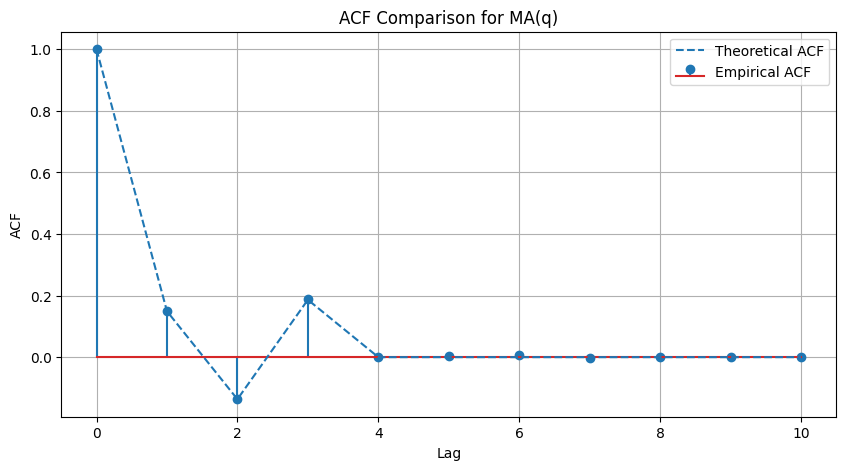

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# MOVING AVERAGE MODEL: MA(q)
# ============================================================
# Mathematical form:
#   X_t = ε_t + θ1*ε_{t-1} + θ2*ε_{t-2} + ... + θq*ε_{t-q}
#
# where:
#   ε_t ~ White Noise (0, σ^2)
#   E[ε_t] = 0
#   Var(ε_t) = σ^2
#   Cov(ε_t, ε_{t-k}) = 0 for k ≠ 0
#
# Key properties we want to VERIFY using simulation:
#   1. E[X_t] = 0
#   2. Var(X_t) = σ^2 (1 + θ1² + θ2² + ... + θq²)
#   3. ACVF (γ_k) becomes 0 after lag q
#   4. ACF (ρ_k) cuts off after lag q
# ============================================================


# -----------------------------
# STEP 1: SET PARAMETERS
# -----------------------------
np.random.seed(42)  # ensures reproducibility

n = 100000          # large dataset (so theory ≈ reality)
q = 3               # order of MA model

# θ parameters (model coefficients)
theta = [0.6, -0.4, 0.3]

sigma = 2           # standard deviation of white noise

# -----------------------------
# STEP 2: GENERATE WHITE NOISE
# -----------------------------
# We generate extra q values because MA(q) depends on past q terms
eps = np.random.normal(loc=0, scale=sigma, size=n + q)

# -----------------------------
# STEP 3: GENERATE MA(q) SERIES
# -----------------------------
# Initialize time series
X = np.zeros(n)

# Construct X_t using definition
for t in range(n):
    # Start with current white noise ε_t
    X[t] = eps[t + q]

    # Add lagged noise terms θ_i * ε_{t-i}
    for i in range(q):
        X[t] += theta[i] * eps[t + q - i - 1]

# At this point, X is our simulated MA(q) process


# ============================================================
# THEORETICAL VALUES
# ============================================================

# Include θ0 = 1 (important for formulas)
theta_full = [1] + theta

# -----------------------------
# THEORETICAL MEAN
# -----------------------------
# Since all ε_t have mean 0:
#   E[X_t] = 0
theoretical_mean = 0


# -----------------------------
# THEORETICAL VARIANCE
# -----------------------------
# Var(X_t) = σ² (1 + θ1² + θ2² + ... + θq²)
theoretical_var = sigma**2 * sum(t**2 for t in theta_full)


# -----------------------------
# THEORETICAL ACVF
# -----------------------------
# γ(k) = σ² * Σ (θ_j * θ_{j+k})
# Only valid for k ≤ q
# For k > q → γ(k) = 0
def theoretical_acvf(k):
    if k > q:
        return 0
    return sigma**2 * sum(theta_full[j] * theta_full[j + k]
                          for j in range(q + 1 - k))


# -----------------------------
# THEORETICAL ACF
# -----------------------------
# ρ(k) = γ(k) / γ(0)
def theoretical_acf(k):
    return theoretical_acvf(k) / theoretical_acvf(0)


# ============================================================
# EMPIRICAL (FROM DATA)
# ============================================================

# -----------------------------
# EMPIRICAL MEAN & VARIANCE
# -----------------------------
emp_mean = np.mean(X)
emp_var = np.var(X)


# -----------------------------
# EMPIRICAL ACVF
# -----------------------------
def empirical_acvf(x, lag):
    n = len(x)
    mean = np.mean(x)

    # Cov(X_t, X_{t-lag})
    return np.sum((x[:n-lag] - mean) * (x[lag:] - mean)) / n


# -----------------------------
# EMPIRICAL ACF
# -----------------------------
def empirical_acf(x, lag):
    return empirical_acvf(x, lag) / empirical_acvf(x, 0)


# ============================================================
# STEP 4: RESULTS COMPARISON
# ============================================================

print("====================================================")
print("MEAN COMPARISON")
print("====================================================")
print("Theoretical Mean :", theoretical_mean)
print("Empirical Mean   :", emp_mean)

print("\n====================================================")
print("VARIANCE COMPARISON")
print("====================================================")
print("Theoretical Variance :", theoretical_var)
print("Empirical Variance   :", emp_var)


print("\n====================================================")
print("ACVF & ACF COMPARISON")
print("====================================================")

max_lag = 10

for k in range(max_lag + 1):
    print(f"\nLag {k}:")
    print("  Theoretical ACVF :", theoretical_acvf(k))
    print("  Empirical ACVF   :", empirical_acvf(X, k))
    print("  Theoretical ACF  :", theoretical_acf(k))
    print("  Empirical ACF    :", empirical_acf(X, k))


# ============================================================
# STEP 5: VISUALIZATION
# ============================================================

lags = range(max_lag + 1)

emp_acf_vals = [empirical_acf(X, k) for k in lags]
theo_acf_vals = [theoretical_acf(k) for k in lags]

plt.figure(figsize=(10,5))

# Empirical ACF (stem plot)
plt.stem(lags, emp_acf_vals, label='Empirical ACF')

# Theoretical ACF (line)
plt.plot(lags, theo_acf_vals, linestyle='--', label='Theoretical ACF')

plt.title("ACF Comparison for MA(q)")
plt.xlabel("Lag")
plt.ylabel("ACF")

plt.legend()
plt.grid()

plt.show()